# Practical Exercise to learn Prophet library

## Part 1: Importing the dataset and experimenting with Prophet

In [2]:
pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 20.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [prophet]m4/5 [prophet]y]

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet


Reading the **open access TFL dataset**  providing information on the total number of daily hires for Santander bikes over a period of approximately seven years.  

The dataset can be downloaded from the following website:

https://data.london.gov.uk/dataset/number-bicycle-hires

The data is loaded using pandas `read_excel()` method.

In [4]:
df_data = pd.read_excel("data/tfl-daily-cycle-hires.xls", sheet_name="Data")
df_data = df_data[["Day", "Number of Bicycle Hires"]]
df_data["Day"] = df_data["Day"].dt.date
df_data.head(10)

,Day,Number of Bicycle Hires
0,2010-07-30,6897
1,2010-07-31,5564
2,2010-08-01,4303
3,2010-08-02,6642
4,2010-08-03,7966
5,2010-08-04,7893
6,2010-08-05,8724
7,2010-08-06,9797
8,2010-08-07,6631
9,2010-08-08,7864


Plot the time series of the Number of Bicycle Hires over time using the `plt.plot()` function from `matplotlib`

Use values in column **'Day'** as **'x'** and values in column **'Number of Bicycle Hires'** as **'y'**

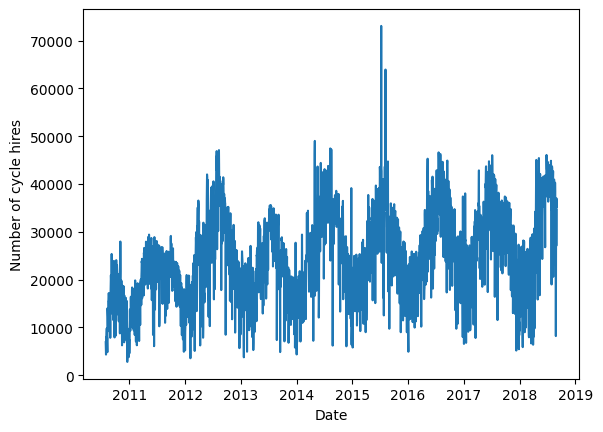

In [5]:
# Your code here...
plt.plot(df_data["Day"], df_data["Number of Bicycle Hires"])
plt.xlabel("Date")
plt.ylabel("Number of cycle hires")
plt.show()


Plot the **Histogram** of the Daily **'Number of Bicycle Hires'**. Please use `plt.hist()` function with 50 bins.

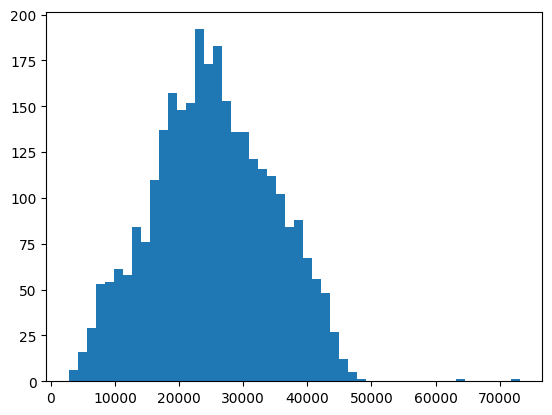

In [6]:
# Your code here...
plt.hist((df_data["Number of Bicycle Hires"]), bins=50)
plt.show()


Prepare the data in a format suitable for applying **Prophet**.
The **the first column** should indicate the **time** and **the second column** should contain **the time series** values.

Please rename the columns to names `ds` and `y` accordingly. Please use `.rename()` method from `pandas`. This method expects a dictionary mapping old column names to new ones.

In [7]:
# Your code here...
df_data = df_data.rename(columns={"Day": "ds", "Number of Bicycle Hires": "y"})
df_data.head()


,ds,y
0,2010-07-30,6897
1,2010-07-31,5564
2,2010-08-01,4303
3,2010-08-02,6642
4,2010-08-03,7966


### Including one-off effects: **Bank Holidays**

- Create a DataFrame called `bank_holidays` with columns `holiday` and `ds`
- Load information about bank holidays from file `data/BankHolidayLists.csv` and use only information from `Date` column as `ds`
- Set all values in `holiday` column equal to `BankHoliday`

In [8]:
# Your code here...
dates = pd.to_datetime(list(pd.read_csv("data/BankHolidayLists.csv")["Date"]))
bank_holidays = pd.DataFrame({"holiday": "BankHoliday", "ds": dates})
bank_holidays.head()


,holiday,ds
0,BankHoliday,2009-01-01
1,BankHoliday,2009-04-10
2,BankHoliday,2009-04-13
3,BankHoliday,2009-05-04
4,BankHoliday,2009-05-25


### Including one-off effects: **Strike Days**

- Create a DataFrame called `strike_days` with columns `holiday` and `ds`
- Set values in column `ds` equal to ['2017-08-05', '2017-08-06', '2017-02-06', '2015-07-09', '2015-07-08', '2015-03-08']
- Set all values in `holiday` column equal to `strike`

In [9]:
# Your code here...
dates = pd.to_datetime(
    ["2017-08-05", "2017-08-06", "2017-02-06", "2015-07-09", "2015-07-08", "2015-03-08"]
)
strike_days = pd.DataFrame({"holiday": "strike", "ds": dates})
strike_days.head()


,holiday,ds
0,strike,2017-08-05
1,strike,2017-08-06
2,strike,2017-02-06
3,strike,2015-07-09
4,strike,2015-07-08


### Including one-off effects: combine **Strike Days** and **Bank Holidays**

- Concatenate DataFrames `bank_holidays` and `strike_days`

In [10]:
# Your code here...
all_holidays_strikes = pd.concat((bank_holidays, strike_days))
all_holidays_strikes["ds"] = all_holidays_strikes["ds"].dt.date
all_holidays_strikes.tail(n=10)


,holiday,ds
92,BankHoliday,2020-05-25
93,BankHoliday,2020-08-31
94,BankHoliday,2020-12-25
95,BankHoliday,2020-12-28
0,strike,2017-08-05
1,strike,2017-08-06
2,strike,2017-02-06
3,strike,2015-07-09
4,strike,2015-07-08
5,strike,2015-03-08


## Fitting the model

- Create a Prophet model using `Prophet()` with parameter `holidays=all_holidays_strikes` and all other parameters being default
- Call `.fit(df_data)` on the model

In [11]:
# Your code here...
forecast_model = Prophet(holidays=all_holidays_strikes)
forecast_model.fit(df_data)


23:56:45 - cmdstanpy - INFO - Chain [1] start processing
23:56:47 - cmdstanpy - INFO - Chain [1] done processing


## Plotting predictions

- Create a `DataFrame` named `df_dates` by calling `.make_future_dataframe(periods=365, include_history=True)` method on the model
- Call method `.predict(df_dates)` on the model and save predictions to `model_predictions`
- Plot model predictions by calling `.plot(model_predictions)` on the model. Save the plot to `plot_pred`

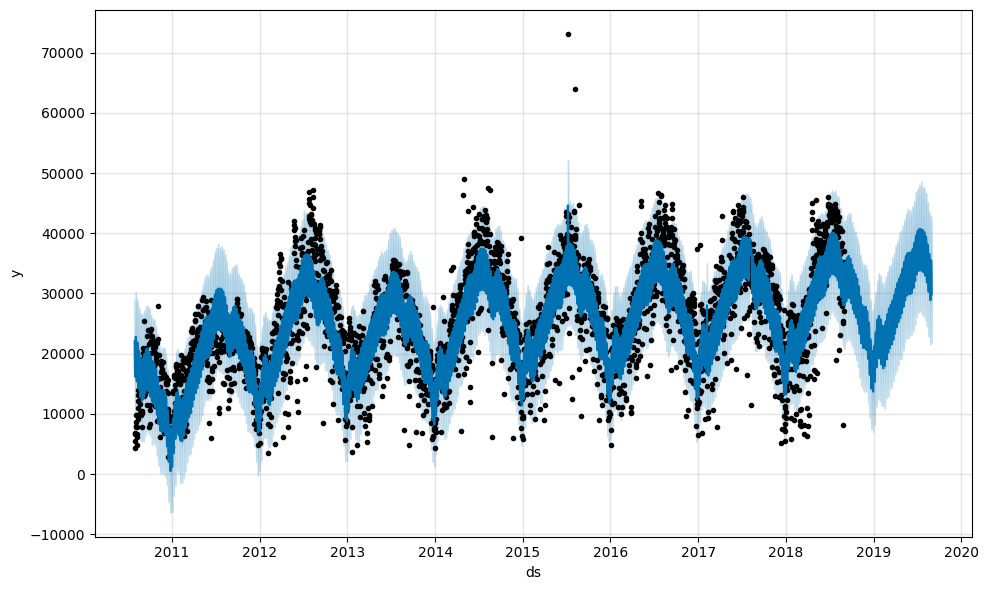

In [12]:
# Your code here...
df_dates = forecast_model.make_future_dataframe(periods=365, include_history=True)
model_predictions = forecast_model.predict(df_dates)
plot_pred = forecast_model.plot(model_predictions)


## Plotting Model Components

- Plot model Components  by calling `.plot_components(model_predictions)` on the model. Save the plot to `plot_components`

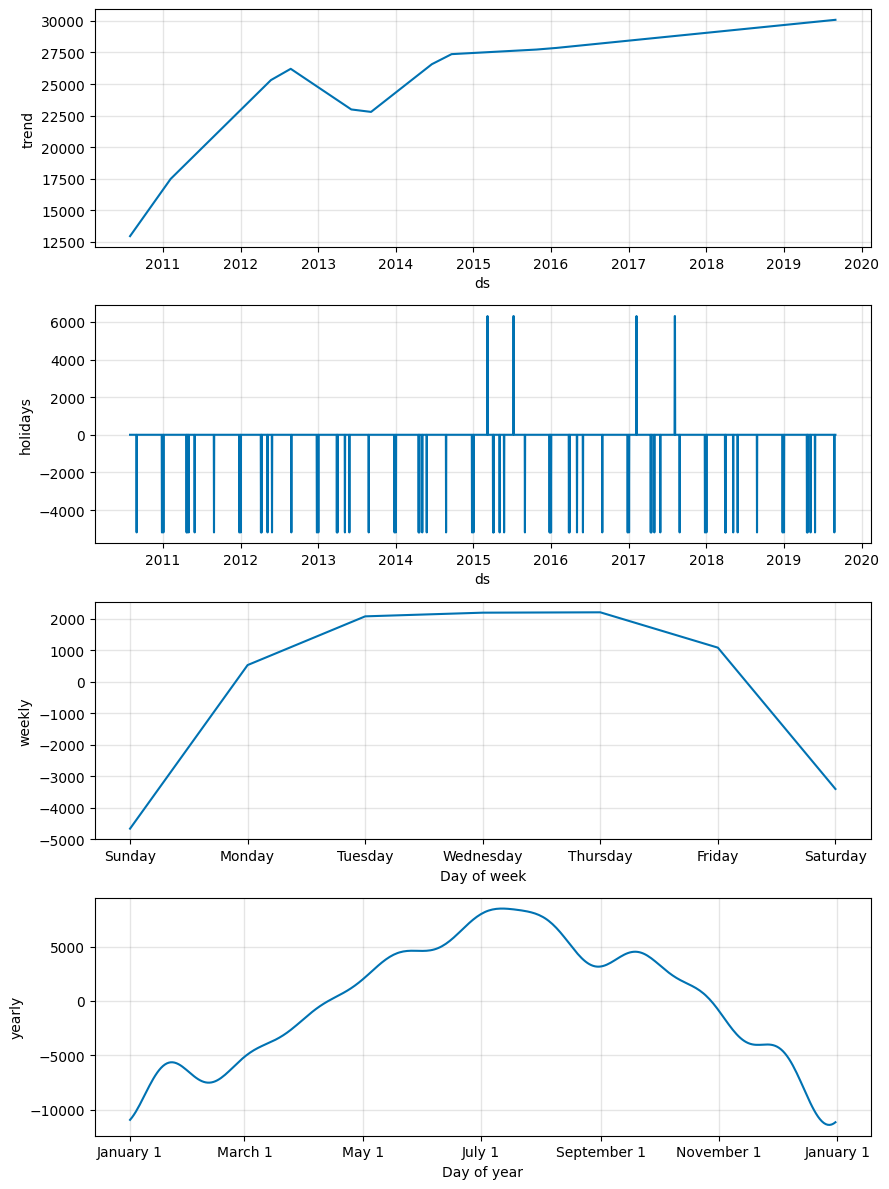

In [13]:
# Your code here...
plot_components = forecast_model.plot_components(model_predictions, uncertainty=False)


## Part 2: Experimenting with Seasonalities and Changepoints in Prophet

### Experimenting with seasonality parameters - Good Fit

- Create a Prophet model using `Prophet()` with parameter `holidays=all_holidays_strikes` and set `weekly_seasonality=3` and `yearly_seasonality=3`
- Repeat all other steps outlined above: fit the data, plot predictions and plot the components

23:56:49 - cmdstanpy - INFO - Chain [1] start processing
23:56:49 - cmdstanpy - INFO - Chain [1] done processing


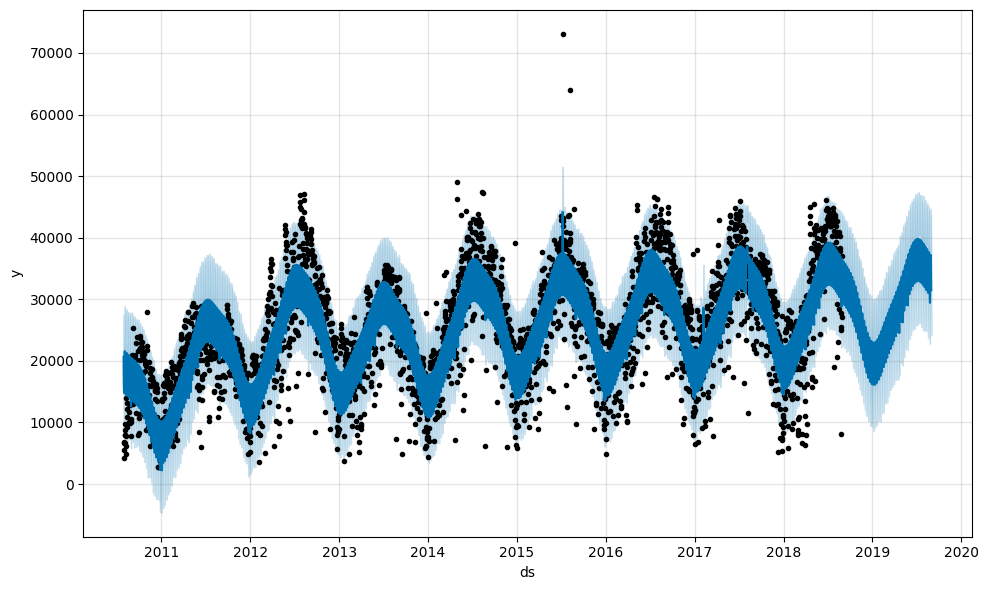

In [14]:
# Your code here...
forecast_model = Prophet(
    holidays=all_holidays_strikes,
    weekly_seasonality=3,
    yearly_seasonality=3,
    daily_seasonality=False,
)
forecast_model.fit(df_data)
df_dates = forecast_model.make_future_dataframe(periods=365, include_history=True)
model_predictions = forecast_model.predict(df_dates)
plot_pred = forecast_model.plot(model_predictions)


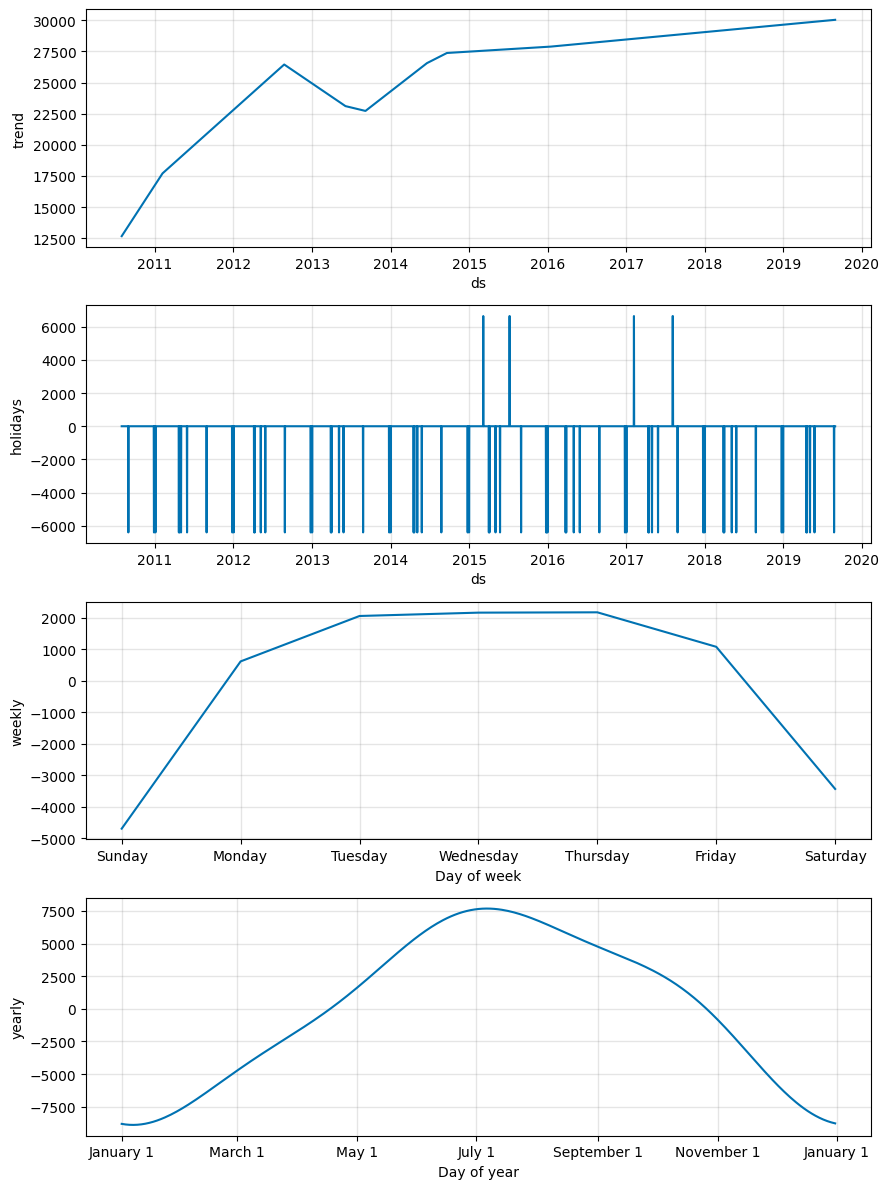

In [15]:
# Your code here...
plot_components = forecast_model.plot_components(model_predictions, uncertainty=False)


### Experimenting with seasonality parameters - Underfitting

- Create a Prophet model using `Prophet()` with parameter `holidays=all_holidays_strikes` and set `weekly_seasonality=1` and `yearly_seasonality=1`
- Repeat all other steps outlined above: fit the data, plot predictions and plot the components

23:56:50 - cmdstanpy - INFO - Chain [1] start processing
23:56:51 - cmdstanpy - INFO - Chain [1] done processing


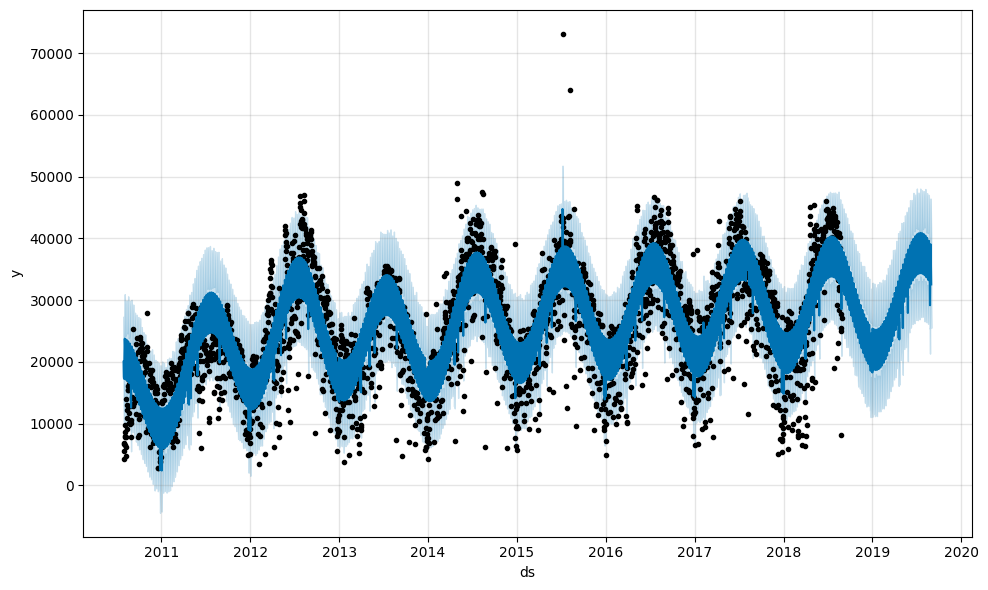

In [16]:
# Your code here...
forecast_model = Prophet(
    holidays=all_holidays_strikes,
    weekly_seasonality=1,
    yearly_seasonality=1,
    daily_seasonality=False,
)
forecast_model.fit(df_data)
df_dates = forecast_model.make_future_dataframe(periods=365, include_history=True)
model_predictions = forecast_model.predict(df_dates)
plot_pred = forecast_model.plot(model_predictions)


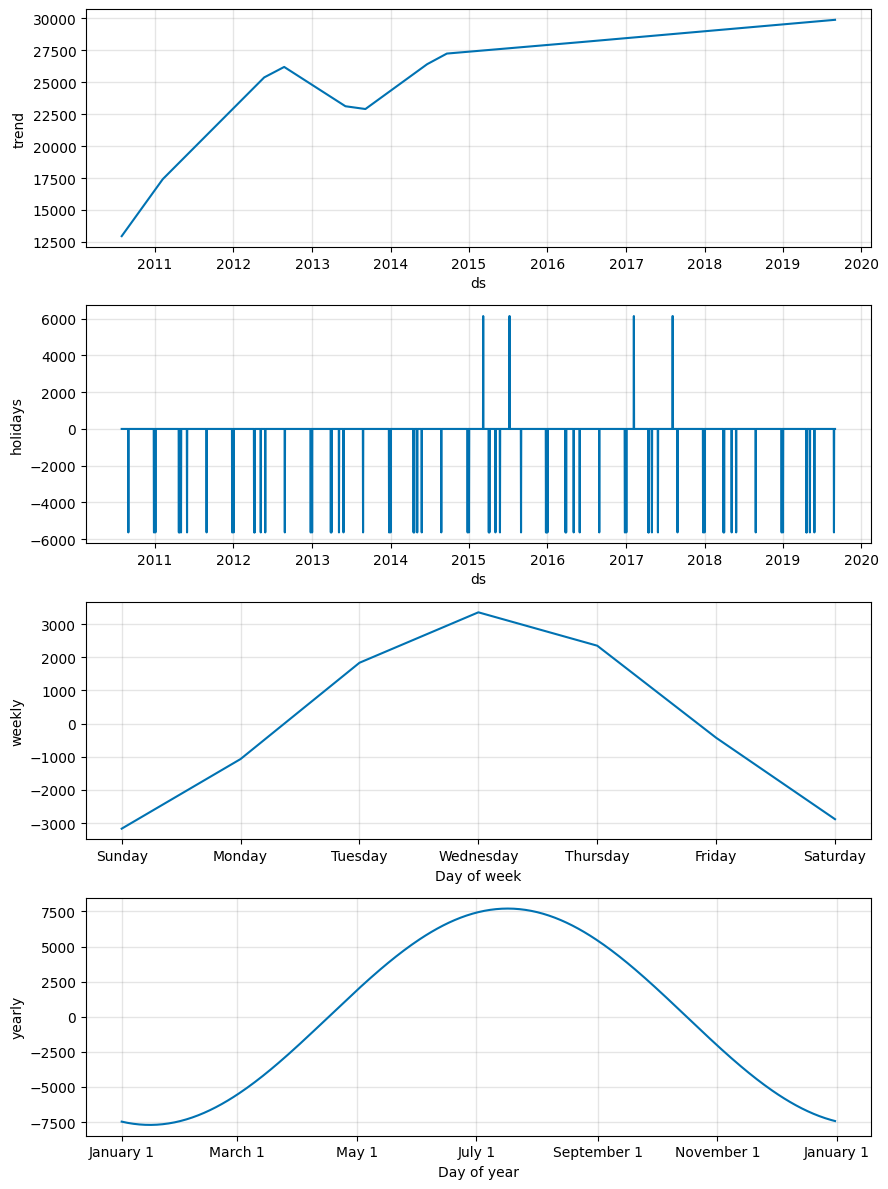

In [17]:
# Your code here...
plot_components = forecast_model.plot_components(model_predictions, uncertainty=False)


### Experimenting with seasonality parameters - Overfitting

- Create a Prophet model using `Prophet()` with parameter `holidays=all_holidays_strikes` and set `weekly_seasonality=20` and `yearly_seasonality=20`
- Repeat all other steps outlined above: fit the data, plot predictions and plot the components

23:56:53 - cmdstanpy - INFO - Chain [1] start processing
23:56:54 - cmdstanpy - INFO - Chain [1] done processing


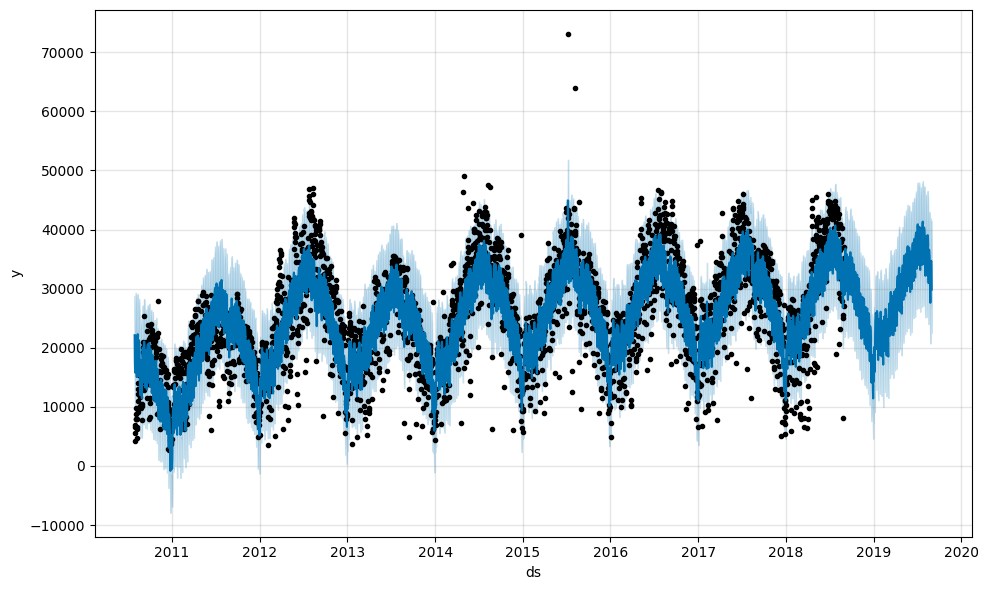

In [18]:
# Your code here...
forecast_model = Prophet(
    holidays=all_holidays_strikes,
    weekly_seasonality=20,
    yearly_seasonality=20,
    daily_seasonality=False,
)
forecast_model.fit(df_data)
df_dates = forecast_model.make_future_dataframe(periods=365, include_history=True)
model_predictions = forecast_model.predict(df_dates)
plot_pred = forecast_model.plot(model_predictions)


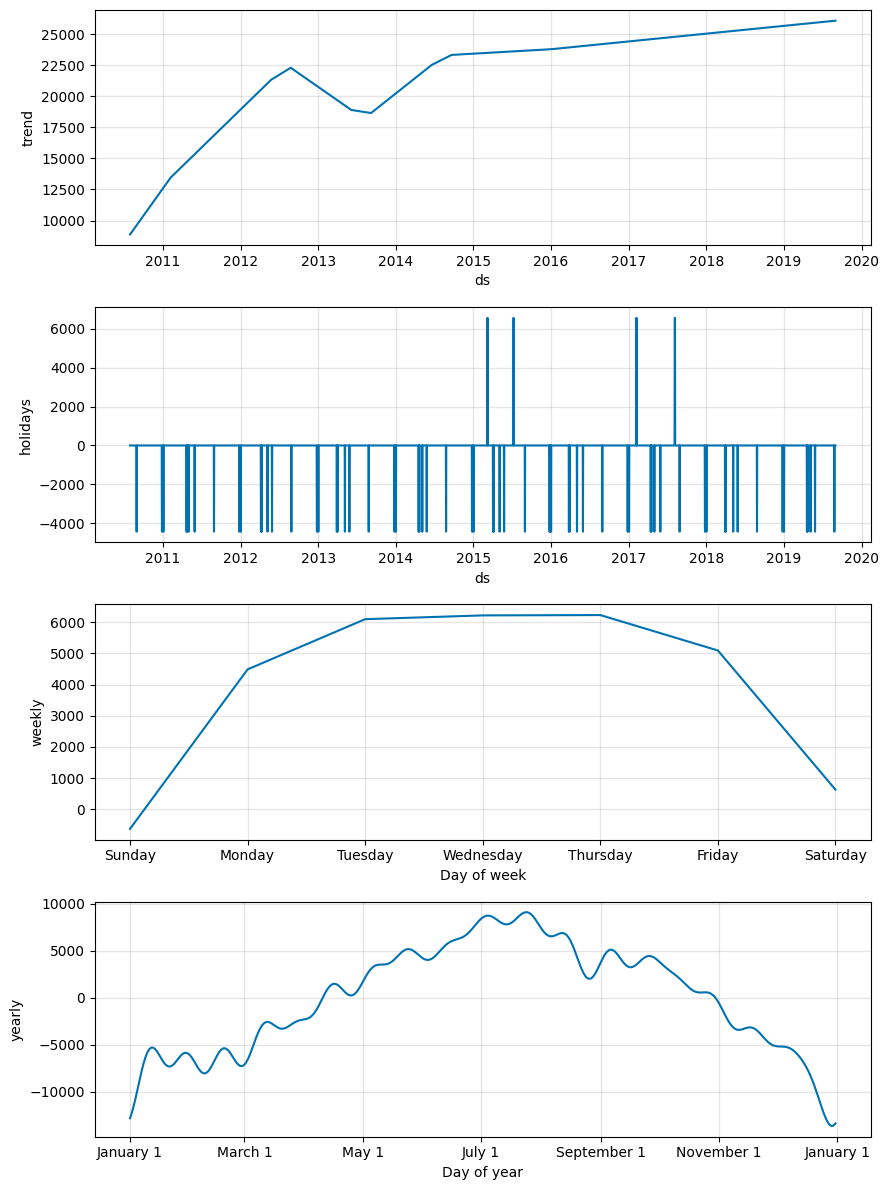

In [19]:
# Your code here...
plot_components = forecast_model.plot_components(model_predictions, uncertainty=False)


### Results comparison

- Compare the plots obtained by models with different seasonality parameters
- Do you agree that the model with `yearly_seasonality=20` appears to be **overfitting**? Why do you think this is happening?
- Do you agree that the model with `yearly_seasonality=1` appears to be **underfitting**? Why do you think this is happening?

## Experimenting with Change Points

Import the `add_changepoints_to_plot` method from `prophet`

In [20]:
from prophet.plot import add_changepoints_to_plot

#### Fitting the model

- Create a Prophet model using `Prophet()` with parameter `holidays=all_holidays_strikes` and set `weekly_seasonality=3` and `yearly_seasonality=3`
- Repeat all other steps outlined above: fit the data, make_future_dataframe and call run prediction

In [21]:
# Your code here...
forecast_model = Prophet(
    holidays=all_holidays_strikes,
    weekly_seasonality=3,
    yearly_seasonality=3,
    daily_seasonality=False,
)
forecast_model.fit(df_data)
df_dates = forecast_model.make_future_dataframe(periods=365, include_history=True)
model_predictions = forecast_model.predict(df_dates)


23:56:55 - cmdstanpy - INFO - Chain [1] start processing
23:56:56 - cmdstanpy - INFO - Chain [1] done processing


- Call method `.plot()` on model predictions and save the figure to `fig`
- Call method `add_changepoints_to_plot()` with parameters `fig.gca()`, the model itself and model predictions

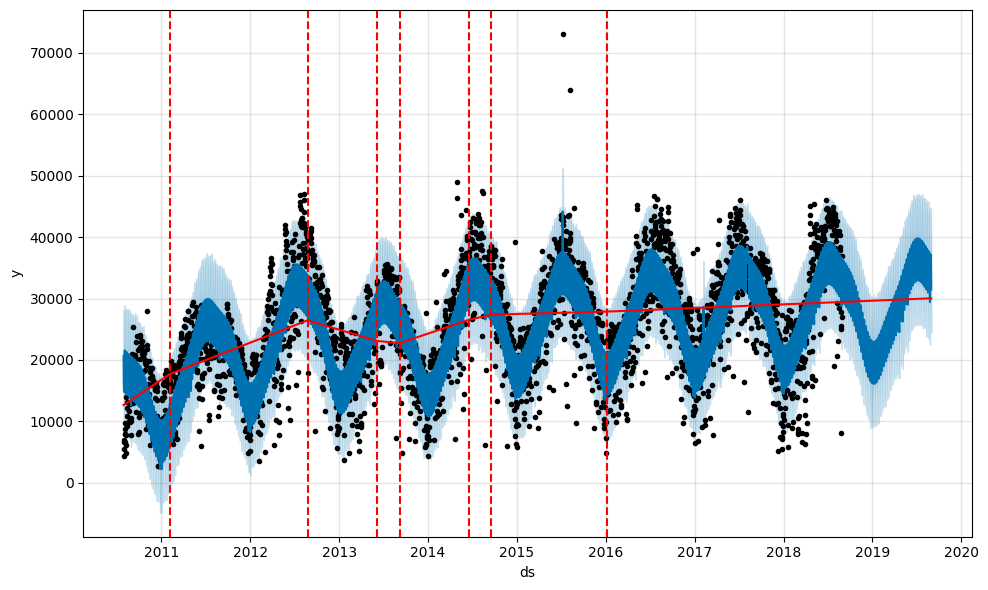

In [22]:
# Your code here...
fig = forecast_model.plot(model_predictions)
changepoint_plot = add_changepoints_to_plot(
    fig.gca(), forecast_model, model_predictions
)


- Explore the change points of the graph
- Compare the change points with the **trend** graph in the plot of components
- Are the change points clearly visible in the **trend**?